Available grid configurations:
1. small
2. large
3. open
4. trap_corridor
5. suboptimal_trap
6. loop_trap
7. bottleneck_maze
8. scattered_walls
9. banded_obstacles
10. spiral_maze
11. goal in the middle



Select configuration (number):  11


Grid size: 5x5


Enter start X position:  0
Enter start Y position:  0


Step 0: Agent at (0, 0), Action: down
  Traj: [(0, 0), (1, 0), (2, 0), (3, 0)], Value: 386.30
  Traj: [(0, 0), (1, 0), (2, 0), (2, 1)], Value: 387.90
  Traj: [(0, 0), (1, 0), (1, 1), (0, 1)], Value: 386.70
  Traj: [(0, 0), (1, 0), (1, 1), (2, 1)], Value: 388.30
  Traj: [(0, 0), (1, 0), (1, 1), (1, 2)], Value: 388.30
  Traj: [(0, 0), (0, 1), (1, 1), (2, 1)], Value: 388.30
  Traj: [(0, 0), (0, 1), (1, 1), (1, 0)], Value: 386.70
  Traj: [(0, 0), (0, 1), (1, 1), (1, 2)], Value: 388.30
  Traj: [(0, 0), (0, 1), (0, 2), (1, 2)], Value: 387.90
  Traj: [(0, 0), (0, 1), (0, 2), (0, 3)], Value: 386.30
Step 1: Agent at (1, 0), Action: down
  Traj: [(1, 0), (0, 0), (0, 1), (1, 1)], Value: 387.20
  Traj: [(1, 0), (0, 0), (0, 1), (0, 2)], Value: 385.20
  Traj: [(1, 0), (2, 0), (3, 0), (4, 0)], Value: 388.70
  Traj: [(1, 0), (2, 0), (3, 0), (3, 1)], Value: 390.70
  Traj: [(1, 0), (2, 0), (2, 1), (1, 1)], Value: 390.20
  Traj: [(1, 0), (2, 0), (2, 1), (3, 1)], Value: 391.20
  Traj: [(1, 0), (2, 0), (2,

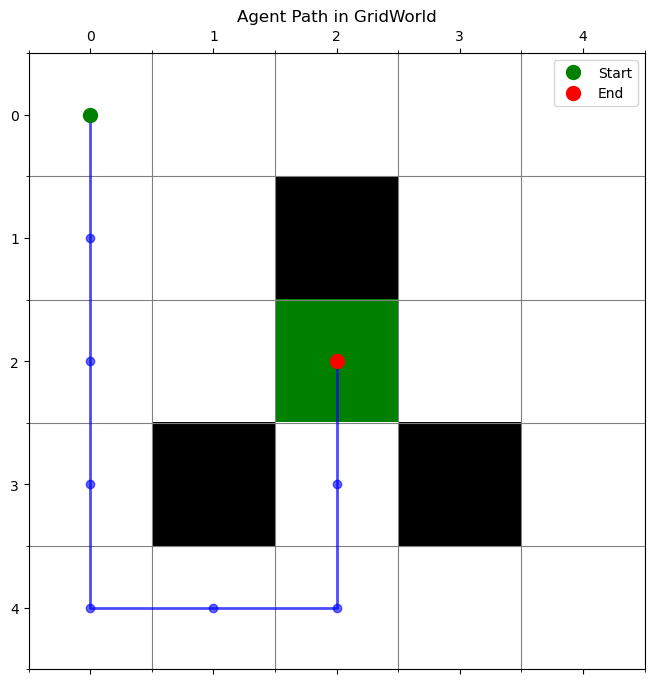

In [3]:
import numpy as np
import random
from collections import defaultdict
import itertools

def manhattan_distance(loc1, loc2):
    ''''''
    return abs(loc1[0] - loc2[0]) + abs(loc1[1] - loc2[1])

def generate_initial_belief(grid_size, agent_loc, known_adjacent_walls, goal_distance, max_walls=1):
    """
    Generates belief over each grid cell compatible with:
    - Fixed agent location
    - Known wall status in adjacent cells
    - Unknown walls/rewards elsewhere 
    Returns:
    dict: Belief distribution {cell: probability} with each cell having a probability distribution in the form of a tuple 
    with the possibility of being clear, wall or reward location
    Generate initial belief over each grid cell, with constraint:
    - Reward can only exist in cells at Manhattan distance = goal_distance.
    """
    height, width = grid_size
    all_cells = set(itertools.product(range(height), range(width)))
    
    # Get adjacent cells (4-direction neighbors)
    adjacent = set()
    for dx, dy in [(0,1), (1,0), (0,-1), (-1,0)]:
        nx, ny = agent_loc[0] + dx, agent_loc[1] + dy
        if 0 <= nx < height and 0 <= ny < width:
            adjacent.add((nx, ny))
    
    # Known free adjacent cells (adjacent - known walls)
    known_adjacent_free = adjacent - known_adjacent_walls
    
    # Fixed cells (agent + adjacent)
    fixed_cells = {agent_loc} | adjacent
    variable_cells = all_cells - fixed_cells
    
    # Identify candidate goal cells (at the correct distance)
    candidate_goal_cells = {cell for cell in variable_cells 
                            if manhattan_distance(agent_loc, cell) == goal_distance}
    num_goal_candidates = len(candidate_goal_cells)
    
    belief = {}
    for cell in variable_cells:
        if cell in candidate_goal_cells:
            # reward probability spread uniformly among valid candidates
            p_reward = 1.0 / num_goal_candidates if num_goal_candidates > 0 else 0.0
            # remaining split between clear & wall (say equally)
            p_clear = (1 - p_reward) / 2
            p_wall = (1 - p_reward) / 2
        else:
            # cannot be goal cell
            p_reward = 0.0
            p_clear, p_wall = 0.5, 0.5
        belief[cell] = (p_clear, p_wall, p_reward)

    for cell in fixed_cells:
        if cell == agent_loc or cell in known_adjacent_free:
            belief[cell] = (1, 0, 0)
        elif cell in known_adjacent_walls:
            belief[cell] = (0, 1, 0)
        
    return belief


def fixed_reward(grid_size, reward_loc):
    rows, columns = grid_size
    reward = {}
    for r in range(rows):
        for c in range(columns):
            cell = (r,c)
            reward[cell] = manhattan_distance(cell, reward_loc)

    return reward

class GridWorldPOMDP:
    def __init__(self, grid_size, agent_pos, reward_loc, wall_locs, lookahead_depth, rewards={'L': 10}, costs={'move': -0.1, 'null': -5.0}, R_max=100):
        self.grid_size = grid_size
        self.agent_pos = agent_pos
        self.reward_loc = reward_loc
        self.wall_locs = set(wall_locs)
        self.fixed_reward_for_cell = fixed_reward(grid_size, reward_loc)
        # Calculate adjacent cells to agent
        adjacent_cells = self.get_adjacent_positions(self.agent_pos)
        
        # Determine known adjacent walls (intersection of adjacent cells and actual walls)
        known_adjacent_walls = set(adjacent_cells) & set(self.wall_locs)

        # From fixed_reward, compute true distance to goal
        self.goal_distance = self.fixed_reward_for_cell[self.agent_pos]
        
        # Generate initial belief distribution
        self.belief = generate_initial_belief(
            grid_size=self.grid_size,
            agent_loc=self.agent_pos,
            known_adjacent_walls=known_adjacent_walls,
            goal_distance=self.goal_distance,
            max_walls=1
        )

        self.dead_end_cells = set()  # stores cells known to be dead ends
        self.best_trajectory = None 
        self.last_pos = None  # for keeping track of last position of the agent in the previous lookahead
        self.visited_global = set()


              
        self.actions = ['null', 'up', 'down', 'left', 'right']
        self.rewards = rewards
        self.costs = costs
        self.lookahead_depth = lookahead_depth    # number of steps ahead that the agent plans for
        #self.utility_dict = self.utility_fn()
        #self.visit_counts = defaultdict(int)    # to count the number of times a state is visited
        self.wall_history = []
        self.dead_end_cells = set()
        self.current_target = None
            


    def get_adjacent_positions(self, agent_pos):
        """Get set of adjacent grid positions for a given state"""
        x, y = agent_pos
        adjacent_positions = []
    
        for dx, dy in [(0,1), (1,0), (0,-1), (-1,0)]:
            nx, ny = x + dx, y + dy
            if (0 <= nx < self.grid_size[0] and 
                0 <= ny < self.grid_size[1]):
                adjacent_positions.append((nx, ny))
    
        return adjacent_positions
         


    def transition_fn(self, agent_pos, action):
        """
    Given the current agent position and an action, return the next position.
    Considers grid boundaries and walls.
        """
        x, y = agent_pos  # x=row, y=col

        if action == 'null':
            return agent_pos
        elif action == 'up':
            new_loc = (x-1, y)  # row decreases
        elif action == 'down':
            new_loc = (x+1, y)  # row increases
        elif action == 'left':
            new_loc = (x, y-1)  # column decreases
        elif action == 'right':
            new_loc = (x, y+1)  # column increases
        else:
            return agent_pos  # invalid action

    # Check if new_loc is within the grid and not a wall
        if (0 <= new_loc[0] < self.grid_size[0] and
            0 <= new_loc[1] < self.grid_size[1]):
            return new_loc
        else:
            return agent_pos

            

    def observation_fn(self, new_agent_pos):
        """ Generates actual observation based on transitioned state. Returns a dictionary of observations with the actual observations 
        received for the agent location and adjacent cell locations in the transitioned state. """
        
        observations = {}
        
        # Observation for current cell location of agent
        if new_agent_pos == self.reward_loc:
            observations[new_agent_pos] = 'reward'
        else:
            x, y = new_agent_pos
            adjacent_wall = any( (x+dx, y+dy) in self.wall_locs 
                              for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)] )
        
            if adjacent_wall:
                observations[new_agent_pos] = 'near wall'
            else:
                observations[new_agent_pos] = 'clear' 

        # Observation of cells adjacent to agent location
        x, y = new_agent_pos
        for dx, dy in [(0,1), (0,-1), (-1,0), (1,0)]:
            neighbor = (x + dx, y + dy)
        # Only consider valid grid positions
            if 0 <= neighbor[0] < self.grid_size[0] and 0 <= neighbor[1] < self.grid_size[1]:
                if neighbor == self.reward_loc:
                    observations[neighbor] = 'reward'
                elif neighbor in self.wall_locs:
                    observations[neighbor] = 'wall'
                else:
                    observations[neighbor] = 'clear'

        return observations

    

    def update_belief(self, action, agent_pos, observation_dict):
        """
        Proper Bayesian belief update following POMDP formula:
        b'(s') ∝ O(o|s',a) * Σ_s [T(s'|s,a) * b(s)]
    
        Key improvements:
        1. Uses prior belief for each cell independently
        2. Updates agent position AFTER belief calculation
        3. Only updates new position based on observation
        """
    # Create new belief container 
        new_belief = {}
    # Store a copy of original cell beliefs before update
        #prior_cell_belief = self.belief.copy()
    
    # Calculate posteriors using PRIOR beliefs for each cell
        for cell in self.belief:
        # Get PRIOR probabilities for each cell
            p_clear, p_wall, p_reward = self.belief[cell]
        
        # Get observation likelihood for each cell that has been observed
            if cell in observation_dict:
                obs = observation_dict[cell]
                if obs == 'near wall':
                    l_clear, l_wall, l_reward = 1.0, 0.0, 0.0
                elif obs == 'wall':
                    l_clear, l_wall, l_reward = 0.0, 1.0, 0.0
                elif obs == 'clear':
                    l_clear, l_wall, l_reward = 1.0, 0.0, 0.0
                elif obs == 'reward':
                    l_clear, l_wall, l_reward = 0.0, 0.0, 1.0
            else:
            # Unobserved cells: likelihood = 1 for all states
                l_clear, l_wall, l_reward = 1.0, 1.0, 1.0

        
        # Bayesian update for observed cells: posterior ∝ prior * likelihood
            posterior_clear = p_clear * l_clear
            posterior_wall = p_wall * l_wall
            posterior_reward = p_reward * l_reward

            new_belief[cell] = posterior_clear, posterior_wall, posterior_reward
            
        # Updating belief for candidate goal cells based on reward information received from the agent_pos cell i.e. how far it is from the actual goal cell
        reward_info = self.reward_info(agent_pos)
        for cell in new_belief:
            p_clear, p_wall, p_reward = new_belief[cell]
            if p_reward > 0:
                expected = manhattan_distance(agent_pos, cell)
                if expected != reward_info:
                    # This cell cannot be the goal
                    p_reward = 0.0

            new_belief[cell] = (p_clear, p_wall, p_reward)
            
        # Enforce global reward constraint
        if any(obs == 'reward' for obs in observation_dict.values()):
            reward_cell = next(c for c, obs in observation_dict.items() if obs == 'reward')
            for cell in new_belief:
                if cell != reward_cell:
                    p_clear, p_wall, _ = new_belief[cell]
                    total = p_clear + p_wall
                    if total > 0:
                        new_belief[cell] = (p_clear/total, p_wall/total, 0.0)

    #  Normalize probabilities within each cell
        for cell in new_belief:
            p_clear, p_wall, p_reward = new_belief[cell]
            total = p_clear + p_wall + p_reward
            if total > 0:
                new_belief[cell] = (p_clear/total, p_wall/total, p_reward/total)

    #  Normalize reward probabilities across all cells
        total_reward = sum(b[2] for b in new_belief.values())
        if total_reward > 0:
            for cell in new_belief:
                p_clear, p_wall, p_reward = new_belief[cell]
                new_belief[cell] = (p_clear, p_wall, p_reward / total_reward)


        self.belief = new_belief
        return self.belief
                
    
    

    def reward_info(self, agent_pos):
        reward_info = self.fixed_reward_for_cell[agent_pos]
        return reward_info


    def expected_cost(agent_pos, candidates):
        costs = []
        for i, (Gi, pi) in enumerate(candidates):
            cost = manhattan_distance(agent_pos, Gi)

            for j, (Gj, pj) in enumerate(candidates):
                if i == j:
                    continue
                cost += pj * manhattan_distance(Gi, Gj)

            costs.append(cost)

        best_idx = np.argmin(costs)
        return candidates[best_idx][0]  # target goal

    def lookahead(self, new_agent_pos, belief, depth, trajectory=None, prob=1.0, cum_reward=0.0, first_step=False, R_max=100):
        """
        Recursive lookahead to evaluate trajectories.
        Returns list of (trajectory, expected_value).
        """
        if trajectory is None:
            trajectory = [new_agent_pos]

        # Use a high penalty for revisiting globally visited cells to force exploration
        revisit_penalty = -2.0  # Increased penalty

        # Base case: At the end of the lookahead depth, calculate the terminal value.
        if depth == 0:
            expected_future_value = sum(
                (R_max - manhattan_distance(new_agent_pos, g)) * pg
                for g, (pc, pw, pg) in belief.items() if pg > 0
            )
            final_value = cum_reward + expected_future_value
            return [(trajectory, final_value)]

        p_clear, p_wall, p_reward = belief.get(new_agent_pos, (0, 0, 0))

        if p_reward > 0.9:
            final_reward = cum_reward + R_max
            return [(trajectory, final_reward)]

        results = []
        valid_actions = self.agent_valid_actions(agent_pos=new_agent_pos, belief=belief, first_step=first_step)

        for action in valid_actions:
            if action == 'null':
                continue

            next_cell = self.transition_fn(new_agent_pos, action)
            
            # Skip if next_cell is already in the current trajectory.
            if next_cell in trajectory:
                continue

            p_clear, p_wall, p_reward = belief.get(next_cell, (0, 0, 0))
            weight = p_clear + p_reward
            if weight <= 0:
                continue

            # 1. Immediate reward for this step
            immediate_reward = 0.0
            # 2. Penalize globally visited cells (real history)  ### NEW
            if hasattr(self, "visited_global") and next_cell in self.visited_global:  # visited before → smaller reward
                immediate_reward = 0.5* sum(
                    (R_max - manhattan_distance(next_cell, g)) * pg
                    for g, (pc, pw, pg) in belief.items() if pg > 0
                )
            else:  # first time visit → full reward
                immediate_reward = sum(
                    (R_max - manhattan_distance(next_cell, g)) * pg
                    for g, (pc, pw, pg) in belief.items() if pg > 0
                )
                
            movement_cost = self.costs.get('move', -1.0) # Use the correct cost from the config

            # Apply a significant penalty for revisiting globally visited cells.
            if next_cell in self.visited_global:
                movement_cost += revisit_penalty
                
            # 3. Update cumulative reward
            new_cum_reward = cum_reward + immediate_reward + movement_cost 
            new_prob = prob * weight

            sub_trajs = self.lookahead(
                new_agent_pos=next_cell,
                belief=belief,
                depth=depth - 1,
                trajectory=trajectory + [next_cell],
                prob=new_prob,
                cum_reward=new_cum_reward,
                first_step=False,
                R_max=R_max
            )
            results.extend(sub_trajs)

        return results
        

    
    def policy(self, agent_pos, observation_dict=None, first_step=False, belief=None, R_max=100):
        """
        Policy selects the trajectory with the highest expected value
        directly from lookahead, then executes the first step of that trajectory.
        """
        if belief is None:
            belief = self.belief
        if not hasattr(self, "visited_global"):   ### NEW
            self.visited_global = set() 

        # --- 🧩 Step 1: Check immediate neighbors for goal-like cells ---
        valid_actions = self.agent_valid_actions(agent_pos, belief=belief, first_step=first_step)
        for action in valid_actions:
            next_cell = self.transition_fn(agent_pos, action)
            _, _, p_reward = belief.get(next_cell, (0, 0, 0))

        # 🚀 If belief strongly indicates this is a goal → move there immediately
            if p_reward > 0.9:
                self.best_trajectory = [agent_pos, next_cell]
                self.best_value = R_max * p_reward
                self.all_trajectories = [(self.best_trajectory, self.best_value)]
                return action

    # --- 🧩 Step 2: Otherwise use lookahead planning ---

    # Generate all depth-k trajectories from current pos
        trajectories = self.lookahead(
            new_agent_pos=agent_pos,
            belief=belief,
            depth=self.lookahead_depth,
            trajectory=[agent_pos],
            prob=1.0,
            cum_reward=0.0,
            first_step=first_step,
            R_max=R_max
        )

        if not trajectories:
            return 'null'

    # Pick the trajectory with max expected value
        best_traj, best_val = max(trajectories, key=lambda x: x[1])

    # Save for debugging / visualization
        self.best_trajectory = best_traj
        self.best_value = best_val
        self.all_trajectories = trajectories  # store everything for inspection

    # If best trajectory is just [agent_pos], no movement → fallback
        if len(best_traj) < 2:
            return 'null'

    # Otherwise return the first step after current pos
        return self.action_from_transition(agent_pos, best_traj[1])
   
        

    
    def action_from_transition(self, pos, next_pos):
        dx, dy = next_pos[0] - pos[0], next_pos[1] - pos[1]
        if dx == 1 and dy == 0: return 'down'
        if dx == -1 and dy == 0: return 'up'
        if dx == 0 and dy == 1: return 'right'
        if dx == 0 and dy == -1: return 'left'
        return 'null'


    def update_dead_end(self, cell, belief):
        adj_cells = self.get_adjacent_positions(cell)

        wall_or_boundary_count = 0
        free_count = 0

        for c in adj_cells:
        # Out of grid → boundary = wall
            if not (0 <= c[0] < self.grid_size[0] and 0 <= c[1] < self.grid_size[1]):
                wall_or_boundary_count += 1
                continue

        # Believed wall?
            _, p_wall, _ = belief.get(c, (0,0,0))
            if p_wall > 0.9:
                wall_or_boundary_count += 1
            else:
                free_count += 1

    # Dead-end if 3 sides are blocked (walls or boundary) and only 1 is free
        if wall_or_boundary_count >= 3 and free_count == 1:
            self.dead_end_cells.add(cell)

    def detect_corridor_dead_end(self, observation_dict):
        if not hasattr(self, "wall_history"):
            self.wall_history = []

        self.wall_history.append(observation_dict)

        if len(self.wall_history) < 3:
            return False

        last_three = self.wall_history[-3:]

        def is_corridor(obs):
            walls = [pos for pos, val in obs.items() if val == 'wall']
            walls = set(walls)

            vertical = False
            horizontal = False

            for (x, y) in walls:
                if (x+1, y) in walls or (x-1, y) in walls:
                    vertical = True
                if (x, y+1) in walls or (x, y-1) in walls:
                    horizontal = True

            return vertical or horizontal

        return all(is_corridor(obs) for obs in last_three)

        
    def agent_valid_actions(self, agent_pos, observation_dict=None, belief=None, first_step=False):
        """
        Return valid actions for the agent given its current position.
        Uses belief to avoid cells likely to be walls.
        """
        x, y = agent_pos
        valid = ['null']  # staying put is always allowed

        moves = {
            'up':    (x-1, y),
            'down':  (x+1, y),
            'left':  (x, y-1),
            'right': (x, y+1)
        }

        for action, (nx, ny) in moves.items():
            if 0 <= nx < self.grid_size[0] and 0 <= ny < self.grid_size[1]:

            # Determine wall info
                p_wall = 0.0
                #if first_step:
                # At first step, use known adjacent walls
                #    adjacent = self.get_adjacent_positions(agent_pos)
                #    known_adjacent_walls = set(adjacent) & self.wall_locs
                 #   if (nx, ny) in known_adjacent_walls:
                  #      p_wall = 1.0
                #else:
                # Use belief if provided
                if belief is not None:
                    _, p_wall, _ = belief.get((nx, ny), (0,0,0))
                # Otherwise, use observation dict if available
                elif observation_dict is not None:
                    obs = observation_dict.get((nx, ny), None)
                    if obs == 'wall':
                        p_wall = 1.0

                if p_wall < 0.9:  # allow move if not believed to be a wall
                    valid.append(action)

        return valid



    def extract_reward_probabilities(self, belief, grid_size):
        width, height = grid_size
        reward_probs = np.zeros((height, width))
        for (x, y), (p_clear, p_wall, p_reward) in belief.items():
            reward_probs[y, x] = p_reward
        return reward_probs


from configs import GRID_CONFIGS  # Import your configurations
def select_configuration():
    """Let user choose a grid configuration"""
    print("Available grid configurations:")
    for i, name in enumerate(GRID_CONFIGS.keys(), 1):
        print(f"{i}. {name}")
    
    choice = int(input("\nSelect configuration (number): "))
    config_name = list(GRID_CONFIGS.keys())[choice-1]
    return GRID_CONFIGS[config_name]

def get_start_position(grid_size):
    """Get start position from user"""
    print(f"Grid size: {grid_size[0]}x{grid_size[1]}")
    x = int(input("Enter start X position: "))
    y = int(input("Enter start Y position: "))
    return (x, y)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def visualize_gridworld(grid_size, walls, goal, trajectory):
    """
    Visualize the gridworld environment.
    grid_size: (rows, cols)
    walls: list of (row, col) positions
    goal: (row, col)
    trajectory: list of (row, col) positions visited by the agent
    """

    rows, cols = grid_size
    grid = np.zeros((rows, cols))  # 0 = free

    # Mark walls
    for (r, c) in walls:
        grid[r, c] = 1

    # Mark goal
    grid[goal[0], goal[1]] = 2

    # Colormap: free=white, wall=black, goal=green
    cmap = ListedColormap(['white', 'black', 'green'])

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(grid, cmap=cmap, origin='upper')

    if trajectory:
        traj_r, traj_c = zip(*trajectory)
        ax.plot(traj_c, traj_r, 'b-', linewidth=2, alpha=0.7)   # path line
        ax.plot(traj_c, traj_r, 'bo', markersize=6, alpha=0.6)  # path points
        ax.plot(traj_c[0], traj_r[0], 'go', markersize=10, label='Start')  # start
        ax.plot(traj_c[-1], traj_r[-1], 'ro', markersize=10, label='End')  # end

    # Grid lines
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.8)

    ax.set_title('Agent Path in GridWorld')
    ax.legend()
    plt.show()

import matplotlib.pyplot as plt
# Example
def main():
    # Select configuration
    config = select_configuration()
    
    # Get start position
    start_pos = get_start_position(config['grid_size'])
    
    # Initialize MDP
    pomdp = GridWorldPOMDP(
        grid_size=config['grid_size'],
        agent_pos=start_pos,
        rewards=config['rewards'],
        costs=config['costs'],
        reward_loc=config['reward_loc'],
        wall_locs=config['wall_locs'],
        lookahead_depth=config['lookahead_depth'],
    )
    
    # Initialize state
    state = (
        start_pos,
        config['reward_loc'],
        tuple(config['wall_locs']),
    )
    trajectory = [start_pos]

    agent_pos = state[0]
    adjacent_positions = pomdp.get_adjacent_positions(agent_pos)
    current_pos = agent_pos
    current_state = state
    steps = 0
    max_steps = 50
    steps_data = []
    agent_positions = []
    first_step = True   # when agent is at the start, it uwill use known adjacent cells for belief initialization
    observation_dict = None
# Only start loop if not already at goal
    while current_state[0] != pomdp.reward_loc and steps < max_steps:
        action = pomdp.policy(agent_pos, observation_dict=observation_dict, first_step=first_step, R_max=100)
        print(f"Step {steps}: Agent at {current_state[0]}, Action: {action}")
        #print("\nAll explored trajectories:")
        for t, v in pomdp.all_trajectories:
            print(f"  Traj: {t}, Value: {v:.2f}")

        #print(f"\nChosen action: {action}, Best traj: {pomdp.best_trajectory}, Value: {pomdp.best_value:.2f}")

    
    # Take action
        new_agent_pos = pomdp.transition_fn(agent_pos, action)

    # --- Update last_pos here ---
        pomdp.last_pos = agent_pos   # <-- agent is leaving this cell

        # --- Mark new position as globally visited ---
        pomdp.visited_global.add(new_agent_pos)
    
    # Generate observation
        observation_dict = pomdp.observation_fn(new_agent_pos)
    
    # Update belief
        pomdp.update_belief( action, new_agent_pos, observation_dict)
        # ⚡ Check if current cell is a dead-end
        adjacent_cells = pomdp.get_adjacent_positions(new_agent_pos)
    # If all but one adjacent cells are believed walls or boundaries, mark as dead-end
        pomdp.update_dead_end(new_agent_pos, pomdp.belief)


        first_step = False

        steps += 1
        steps_data.append({
        'step': steps,
        'state': current_state,
        'belief': dict(pomdp.belief)  # Convert defaultdict to regular dict
        })

        agent_positions.append(new_agent_pos)

    # Update transitioned agent position and state
        current_pos = new_agent_pos
        current_state = (new_agent_pos, pomdp.reward_loc, tuple(pomdp.wall_locs))
        agent_pos = new_agent_pos
        trajectory.append(current_pos)

    #visualize_belief_heatmaps(steps_data, config['grid_size'], agent_positions)
        
        
    if current_pos == pomdp.reward_loc:
        print(f"Agent reached goal in {steps} steps!")
    else:
        print("Goal not reached")

    # Visualize the path
    visualize_gridworld(
        grid_size=config['grid_size'],
        walls=config['wall_locs'],
        goal=config['reward_loc'],
        trajectory=trajectory
    )
    
if __name__ == "__main__":
    main()